In [2]:
from torch import torch, nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import numpy as np

In [3]:

data = np.load('quickdraw_train.npz')
print(f"keys in files:{data.files}")
train_images = data['x_train']
train_labels = data['y_train']
class_names = data['class_names']

print(train_images.shape)
print(train_labels.shape)
print(len(class_names))


FileNotFoundError: [Errno 2] No such file or directory: 'quickdraw_train.npz'

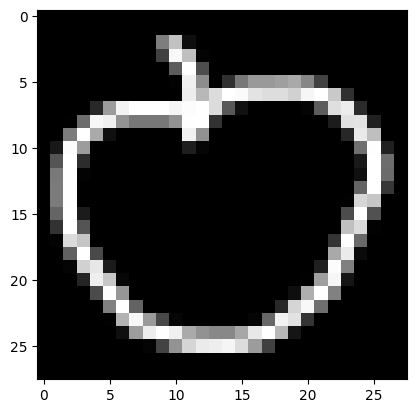

In [ ]:
import matplotlib.pyplot as plt

img_tensor = torch.from_numpy(train_images[0])

img_tensor = img_tensor.view(1, 28, 28)
img_tensor = img_tensor.permute(1, 2, 0)
plt.imshow(img_tensor, cmap='gray')
plt.show()

In [ ]:
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import random_split
def prepare_data(x, y):
  images = torch.from_numpy(x).float()/255.0
  labels = torch.from_numpy(y).long()

  images = images.view(images.shape[0], 1, 28, 28)

  if len(images.shape) > 2:
    images = images.view(images.shape[0], -1)

  print(images.shape)
  print(labels.shape)
  print(labels[0])

  return TensorDataset(images, labels)

In [ ]:

train_data = prepare_data(train_images, train_labels)

generator = torch.Generator().manual_seed(42)
total_size = len(train_data)
train_size = int(0.8 * total_size)
val_size = total_size - train_size
train_data, val_data = random_split(train_data,
                                   [train_size, val_size],
                                    generator=generator)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)


print(f"Train size: {len(train_data)}")
print(f"Val size: {len(val_data)}")

torch.Size([60000, 784])
torch.Size([60000])
tensor(0)
Train size: 48000
Val size: 12000


In [ ]:
BATCH_SIZE = 64
DEVICE = "cpu"

In [ ]:
class WideMLP(nn.Module):
  def __init__(self, input_size=784, num_class=15):
    super(WideMLP, self).__init__()
    self.fc1 = nn.Linear(input_size, 1048)
    self.fc2 = nn.Linear(1048, 1048)
    self.fc3 = nn.Linear(1048, num_class)

  def forward(self, x):
    x0 = x.view(-1, 784)
    x1 = F.relu(self.fc1(x0))
    x2 = F.relu(self.fc2(x1))
    y_hat = self.fc3(x2)
    return y_hat

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [1]:
class DeepMLP(nn.Module):
  def __init__(self, input_size=784, num_class=15):
    super(DeepMLP, self).__init__()

    # self.fc1 = nn.Linear(input_size, 512)
    # self.bn1 = nn.BatchNorm1d(512)
    # self.drop1 = nn.Dropout(0.2)

    # self.fc2 = nn.Linear(512, 512)
    # self.bn2 = nn.BatchNorm1d(512)
    # self.drop2 = nn.Dropout(0.5)

    # self.fc3 = nn.Linear(512, 264)
    # self.bn3 = nn.BatchNorm1d(264)
    # self.drop3 = nn.Dropout(0.2)

    # self.fc4 = nn.Linear(264, 264)
    # self.bn4 = nn.BatchNorm1d(264)
    # self.drop4 = nn.Dropout(0.2)

    # self.fc5 = nn.Linear(264, 128)
    # self.bn5 = nn.BatchNorm1d(128)

    # self.fc6 = nn.Linear(128, num_class)

    # self.fc1 = nn.Linear(input_size, 512)
    # self.bn1 = nn.BatchNorm1d(512)

    # self.fc2 = nn.Linear(512, 448)
    # self.bn2 = nn.BatchNorm1d(448)

    # self.fc3 = nn.Linear(448, 384)
    # self.bn3 = nn.BatchNorm1d(384)

    # self.fc4 = nn.Linear(384, 256)
    # self.bn4 = nn.BatchNorm1d(256)

    # self.fc5 = nn.Linear(256, 128)
    # self.bn5 = nn.BatchNorm1d(128)

    self.fc1 = nn.Linear(input_size, 512)
    self.bn1 = nn.BatchNorm1d(512)

    self.fc2 = nn.Linear(512, 384)
    self.bn2 = nn.BatchNorm1d(384)

    self.fc3 = nn.Linear(384, 256)
    self.bn3 = nn.BatchNorm1d(256)

    self.fc4 = nn.Linear(256, 128)
    self.bn4 = nn.BatchNorm1d(128)

    self.fc5 = nn.Linear(128, 64)
    self.bn5 = nn.BatchNorm1d(64)

    self.fc6 = nn.Linear(64, num_class)

    self.drop_light = nn.Dropout(0.2)
    self.drop_heavy = nn.Dropout(0.5)


  def forward(self, x):
    x = x.view(-1, 784)
    x = self.drop_light(F.gelu(self.bn1(self.fc1(x))))
    x = self.drop_heavy(F.gelu(self.bn2(self.fc2(x))))
    x = self.drop_heavy(F.gelu(self.bn3(self.fc3(x))))
    x = self.drop_light(F.gelu(self.bn4(self.fc4(x))))
    x = F.gelu(self.bn5(self.fc5(x)))
    y_hat = self.fc6(x)
    return y_hat

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

NameError: name 'nn' is not defined

In [241]:

def train_one_epoch(model, train_data, criterion, optimizer):
    model.train()
    total_loss, accurate_predictions, sample_count = 0.0, 0, 0
    for images, labels in train_data:
      images = images.to(DEVICE)
      labels = labels.to(DEVICE)

      images = images.view(-1, 1, 28, 28)
      shift_x, shift_y = np.random.randint(-2,3), np.random.randint(-2,3)
      images = torch.roll(images, shifts=(shift_x, shift_y), dims=(2,3))
      images = images.view(-1, 784)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * images.size(0)
      _, predicted_classes = torch.max(outputs.data, 1)
      accurate_predictions += (predicted_classes == labels).sum().item()
      sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy =  100 * accurate_predictions / sample_count

    return avg_loss, accuracy

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, accurate_predictions, sample_count = 0.0, 0, 0
    with torch.no_grad():
      for images, labels in loader:
          images = images.to(DEVICE)
          labels = labels.to(DEVICE)

          outputs = model(images)
          loss = criterion(outputs, labels)

          _, predicted_classes = torch.max(outputs, 1)

          accurate_predictions += (predicted_classes == labels).sum().item()
          total_loss += loss.item() * images.size(0)
          sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy =  100 * accurate_predictions / sample_count

    return avg_loss, accuracy



In [251]:
import copy
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model_weights = None
def train_model(model:nn.Module, epochs = 40, learning_rate=0.001, weight_decay=1e-3):
  train_losses, train_accs, val_losses, val_accs = [], [], [], []

  best_val_loss = float('inf')
  criterion_cel = nn.CrossEntropyLoss(label_smoothing=0.1)
  optimizer_adam = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode='min', factor=0.4, patience=3, threshold=1e-4)
  for epoch in range(0, epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion=criterion_cel, optimizer=optimizer_adam)
    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion_cel)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_model_weights = copy.deepcopy(model.state_dict())
      print(f"---> Best model updated at Epoch: {epoch+1} (Validation Loss: {val_loss:.4f})")

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_learning_rate = optimizer_adam.param_groups[0]['lr']
    scheduler.step(val_loss)

    print(f"Epoch: {epoch+1}) Training Loss: {train_loss:.4f} Training Accuracy: {train_acc:.2f}% Validation Loss {val_loss:.2f}% Validaion Accuracy:{val_acc:.2f}%")

  model.load_state_dict(best_model_weights)
  torch.save(model.state_dict(), 'best_model_mlp.pth')
  print("Training complete. Loaded best model weights")

  # After training is done:
  print(best_model_weights)
  model.load_state_dict(best_model_weights)
  model.eval()
  all_preds, all_labels = [], []

  with torch.no_grad():
      for images, labels in val_loader:
          outputs = model(images.to(DEVICE))
          all_preds.extend(outputs.argmax(1).cpu().numpy())
          all_labels.extend(labels.numpy())

  cm = confusion_matrix(all_labels, all_preds)
  plt.figure(figsize=(10,8))
  sns.heatmap(cm, annot=True, fmt='d')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()


  return train_losses, train_accs, val_losses, val_accs


In [ ]:
# Initialize Wide model
wide_model = WideMLP().to(DEVICE)
print(f"WideMLP Parameters: {count_parameters(wide_model)}")

EPOCHS = 20
LEARNING_RATE = 0.0005
L2_REGULARIZATION = 1e-3
train_losses, train_acc, val_losses, val_acc = train_model(wide_model, epochs=EPOCHS, learning_rate=L2_REGULARIZATION)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='#1f77b4')
plt.plot(val_losses, label='Validation Loss', color='#1f7f0e')
plt.title('Wide MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Acc', color='#1f77b4')
plt.plot(val_acc, label='Validation Acc', color='#1f7f0e')
plt.title('Wide MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()



DeepMLP Parameters: 941007
---> Best model updated at Epoch: 1 (Validation Loss: 1.3881)
Epoch: 1) Training Loss: 1.6927 Training Accuracy: 51.82% Validation Loss 1.39% Validaion Accuracy:65.61%
---> Best model updated at Epoch: 2 (Validation Loss: 1.3556)
Epoch: 2) Training Loss: 1.5111 Training Accuracy: 59.84% Validation Loss 1.36% Validaion Accuracy:66.38%
---> Best model updated at Epoch: 3 (Validation Loss: 1.2948)
Epoch: 3) Training Loss: 1.4774 Training Accuracy: 61.58% Validation Loss 1.29% Validaion Accuracy:69.60%
Epoch: 4) Training Loss: 1.4606 Training Accuracy: 62.10% Validation Loss 1.32% Validaion Accuracy:69.32%
---> Best model updated at Epoch: 5 (Validation Loss: 1.2785)
Epoch: 5) Training Loss: 1.4459 Training Accuracy: 63.19% Validation Loss 1.28% Validaion Accuracy:71.44%
---> Best model updated at Epoch: 6 (Validation Loss: 1.2686)
Epoch: 6) Training Loss: 1.4360 Training Accuracy: 63.81% Validation Loss 1.27% Validaion Accuracy:71.12%
---> Best model updated at 

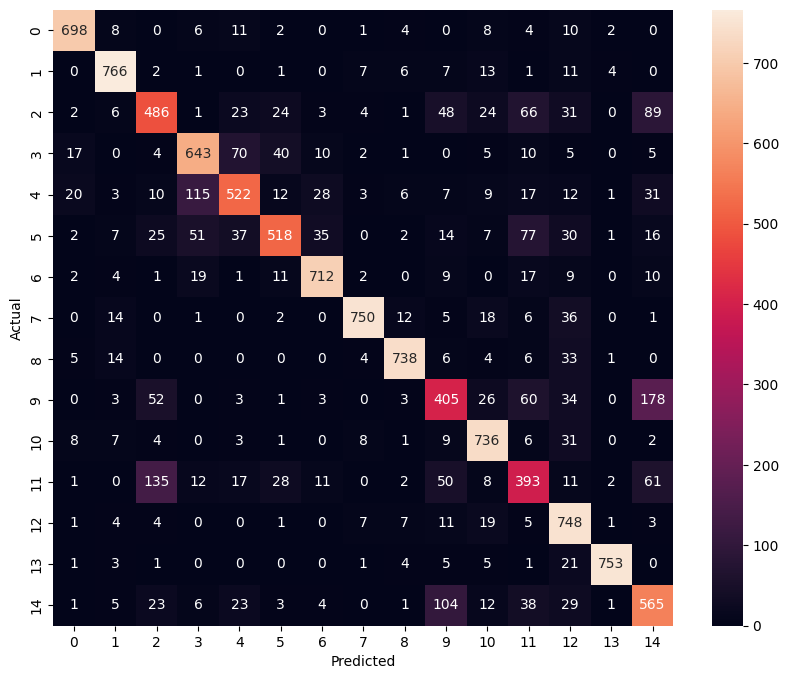

AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_l'

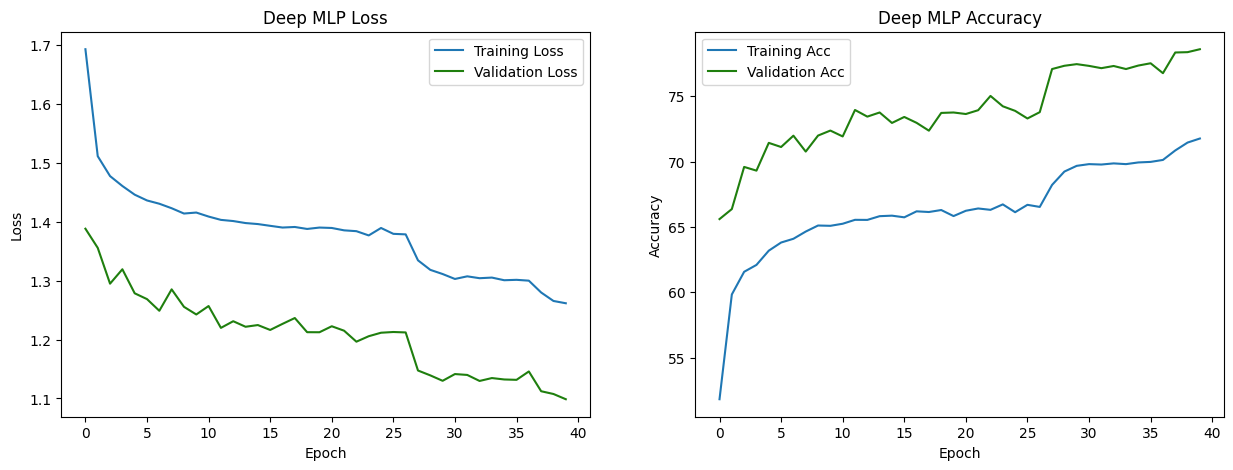

In [252]:
# Initialize Wide model
# Initialize model
deep_model = DeepMLP().to(DEVICE)
print(f"DeepMLP Parameters: {count_parameters(deep_model)}")

EPOCHS = 40
LEARNING_RATE = 0.001
L2_REGULARIZATION = 1e-3
train_losses, train_acc, val_losses, val_acc = train_model(deep_model, epochs=EPOCHS, learning_rate=L2_REGULARIZATION)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='#1f77b4')
plt.plot(val_losses, label='Validation Loss', color='#1f7f0e')
plt.title('Deep MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Acc', color='#1f77b4')
plt.plot(val_acc, label='Validation Acc', color='#1f7f0e')
plt.title('Deep MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_l

In [250]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# After training is done:
print(best_model_weights)
deep_model.load_state_dict(best_model_weights)
deep_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = deep_model(images.to(DEVICE))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

None


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.